# Experiment 8.1 — Per-Attribute Few-Shot LLM + RAG with Improved Prompts

**Key improvements over experiment 8:**
- RAG prompts explicitly instruct the LLM to use ONLY the retrieved KB rows (no own knowledge)
- Full KB row passed to LLM (all meaningful fields, not just selected ones)
- RetClean-inspired approach: LLM first matches the best candidate, then extracts the value
- LLM-only prompts unchanged (no KB available)

**Setup:**
- 25 query rows from Dataset 1 (≥5 instances per attribute)
- KB: full 2,200 rows (all 3 datasets)
- Dual evaluation: standard match + LLM-based judgment

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '/home/ma/ma_ma/ma_mpandya/RAG_Data_Cleaning/PyDI/venv/lib64/python3.12/site-packages')
sys.path.insert(0, '/home/ma/ma_ma/ma_mpandya/RAG_Data_Cleaning/PyDI/venv/lib/python3.12/site-packages')
sys.path.append('/home/ma/ma_ma/ma_mpandya/RAG_Data_Cleaning/PyDI')

import os
os.environ["TRANSFORMERS_OFFLINE"] = "1"

import pandas as pd
import numpy as np
import random
import time
import threading

from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage
from sentence_transformers import SentenceTransformer, util

random.seed(42)
np.random.seed(42)

TARGET_ATTRIBUTES = [
    "bus_type", "model_number", "model",
    "read_speed_mb_s", "write_speed_mb_s",
    "height_mm", "width_mm"
]
NUMERIC_ATTRIBUTES = {"read_speed_mb_s", "write_speed_mb_s", "height_mm", "width_mm"}

# Output file names
USE_RAG = True  # Set to False for LLM-only, True for RAG
LLM_FILE = "results_exp8_1_llm_only.csv"
RAG_FILE = "results_exp8_1_rag.csv"

LLM_HEATMAP_FILE = "heatmap_exp8_1_llm_only.png"
RAG_HEATMAP_FILE = "heatmap_exp8_1_rag.png"
FINAL_HEATMAP_FILE = RAG_HEATMAP_FILE if USE_RAG else LLM_HEATMAP_FILE

RESULT_FILE = RAG_FILE if USE_RAG else LLM_FILE

ALL_LLM = "results_exp8_1_all_LLM.csv"
ALL_RAG = "results_exp8_1_all_RAG.csv"

FINAL_RESULTS_FILE = "results_exp8_1_all.csv"

print(f"Setup complete. USE_RAG={USE_RAG}")

Setup complete. USE_RAG=True


## 2. Load Datasets

In [2]:
df1 = pd.read_json("normalized_products/dataset_1_normalized.json")
df2 = pd.read_json("normalized_products/dataset_2_normalized.json")
df3 = pd.read_json("normalized_products/dataset_3_normalized.json")
df4 = pd.read_json("normalized_products/dataset_4_normalized.json")
kb_full = pd.concat([df2, df3, df4], ignore_index=True)

print(f"Dataset 1: {len(df1)} rows")
print(f"KB full:   {len(kb_full)} rows")

Dataset 1: 812 rows
KB full:   2200 rows


## 3. Build Evaluation Set (25 query rows, ≥5 per attribute)

In [3]:
def get_ground_truth(cluster_id, attribute):
    matches = kb_full[kb_full["cluster_id"] == cluster_id]
    for _, row in matches.iterrows():
        val = row.get(attribute)
        if pd.notna(val) and str(val).strip().lower() not in {"", "none", "nan"}:
            return str(val).strip()
    return None

MIN_PER_ATTR = 5

all_candidates = []
for idx, row in df1.iterrows():
    missing_attrs = []
    for attr in TARGET_ATTRIBUTES:
        if pd.isna(row.get(attr)):
            gt = get_ground_truth(row["cluster_id"], attr)
            if gt is not None:
                missing_attrs.append((attr, gt))
    if missing_attrs:
        all_candidates.append({"df1_idx": idx, "missing_attrs": missing_attrs})

attr_counts = {attr: 0 for attr in TARGET_ATTRIBUTES}
selected_rows = []
selected_idx = set()

for candidate in all_candidates:
    if len(selected_rows) >= 25:
        break
    contributes = any(
        attr_counts[attr] < MIN_PER_ATTR
        for attr, _ in candidate["missing_attrs"]
    )
    if contributes:
        selected_rows.append(candidate)
        selected_idx.add(candidate["df1_idx"])
        for attr, _ in candidate["missing_attrs"]:
            attr_counts[attr] += 1

for candidate in all_candidates:
    if len(selected_rows) >= 25:
        break
    if candidate["df1_idx"] not in selected_idx:
        selected_rows.append(candidate)
        selected_idx.add(candidate["df1_idx"])
        for attr, _ in candidate["missing_attrs"]:
            attr_counts[attr] += 1

eval_records = []
for item in selected_rows:
    for attr, gt in item["missing_attrs"]:
        eval_records.append({
            "df1_idx": item["df1_idx"],
            "attribute": attr,
            "ground_truth": gt,
            "is_numeric": attr in NUMERIC_ATTRIBUTES
        })

eval_df = pd.DataFrame(eval_records)
query_indices = [item["df1_idx"] for item in selected_rows]
query_df = df1.loc[query_indices].copy()

print(f"Query rows:       {len(query_df)}")
print(f"Total eval tasks: {len(eval_df)}")
print()
print("Tasks per attribute:")
print(eval_df["attribute"].value_counts())
print()
print("Attribute coverage check:")
for attr in TARGET_ATTRIBUTES:
    count = (eval_df["attribute"] == attr).sum()
    status = "✓" if count >= MIN_PER_ATTR else "✗ NEED MORE"
    print(f"  {attr:<25} {count:>3} instances  {status}")

Query rows:       25
Total eval tasks: 51

Tasks per attribute:
attribute
model_number        11
read_speed_mb_s     10
bus_type             7
height_mm            7
width_mm             6
write_speed_mb_s     5
model                5
Name: count, dtype: int64

Attribute coverage check:
  bus_type                    7 instances  ✓
  model_number               11 instances  ✓
  model                       5 instances  ✓
  read_speed_mb_s            10 instances  ✓
  write_speed_mb_s            5 instances  ✓
  height_mm                   7 instances  ✓
  width_mm                    6 instances  ✓


## 4. Build Knowledge Base (full 2,200 rows)

In [4]:
# Use full KB as Ralph suggested — no sampling needed
kb = kb_full.copy()
print(f"KB size: {len(kb)} rows")

KB size: 2200 rows


## 5. Sanity Check

In [5]:
print("=== SANITY CHECK: Ground truth present in KB ===\n")
found = 0
not_found = 0
for _, task in eval_df.iterrows():
    idx = task["df1_idx"]
    attr = task["attribute"]
    gt = task["ground_truth"]
    cluster_id = query_df.loc[idx, "cluster_id"]
    kb_matches = kb[kb["cluster_id"] == cluster_id]
    val_in_kb = any(
        pd.notna(r.get(attr)) and str(r.get(attr)).strip() == str(gt).strip()
        for _, r in kb_matches.iterrows()
    )
    status = "✓" if val_in_kb else "✗"
    found += int(val_in_kb)
    not_found += int(not val_in_kb)
    print(f"{status} Row {idx} | {attr:<20} | GT: {str(gt):<30} | KB matches: {len(kb_matches)}")

print(f"\nCoverage: {found}/{found+not_found} = {100*found/(found+not_found):.1f}%")

=== SANITY CHECK: Ground truth present in KB ===

✓ Row 0 | model_number         | GT: GV-N3080GAMING OC-10GD         | KB matches: 3
✓ Row 2 | model_number         | GT: CSSD-F960GBMP510               | KB matches: 3
✓ Row 2 | read_speed_mb_s      | GT: 3480.0                         | KB matches: 3
✓ Row 2 | write_speed_mb_s     | GT: 3000.0                         | KB matches: 3
✓ Row 3 | read_speed_mb_s      | GT: 226.0                          | KB matches: 3
✓ Row 4 | width_mm             | GT: 433.0                          | KB matches: 3
✓ Row 5 | bus_type             | GT: PCIe 3.0 x16                   | KB matches: 3
✓ Row 5 | model_number         | GT: 90YV0CV2-M0NA00                | KB matches: 3
✓ Row 6 | bus_type             | GT: USB 3.0                        | KB matches: 2
✓ Row 8 | model_number         | GT: GV-N166SOC-6GD                 | KB matches: 3
✓ Row 9 | bus_type             | GT: PCIe 3.0 x16                   | KB matches: 3
✓ Row 9 | model_number    

## 6. LLM Setup

In [6]:
predict_model = ChatOllama(model="llama3.1:8b", temperature=0, base_url="http://127.0.0.1:11435")
eval_model = ChatOllama(model="llama3.1:8b", temperature=0, base_url="http://127.0.0.1:11435")

test = predict_model.invoke("Say OK")
print("Ollama OK:", repr(test.content[:20]))

Ollama OK: 'OK'


## 7. Retriever Setup

In [7]:
LOCAL_MODEL_PATH = "/home/ma/ma_ma/ma_mpandya/.cache/huggingface/hub/models--sentence-transformers--all-MiniLM-L6-v2/snapshots/c9745ed1d9f207416be6d2e6f8de32d1f16199bf"

print("Loading embedding model...")
embedding_model = SentenceTransformer(LOCAL_MODEL_PATH)

def row_to_text(row):
    attrs = ["title", "model", "model_number", "brand", "product_type"]
    return " | ".join([str(row[a]) for a in attrs if pd.notna(row.get(a))])

print("Encoding KB...")
kb_texts = kb.apply(row_to_text, axis=1).tolist()
kb_embeddings = embedding_model.encode(
    kb_texts, convert_to_tensor=True,
    batch_size=64, show_progress_bar=True
)
print(f"KB encoded: {len(kb_texts)} rows")

print("Encoding query rows...")
query_texts = query_df.apply(row_to_text, axis=1).tolist()
query_embeddings = embedding_model.encode(
    query_texts, convert_to_tensor=True,
    batch_size=64, show_progress_bar=True
)
print("Query rows encoded.")

query_idx_to_pos = {idx: pos for pos, idx in enumerate(query_df.index)}

Loading embedding model...
Encoding KB...


Batches:   0%|          | 0/35 [00:00<?, ?it/s]

KB encoded: 2200 rows
Encoding query rows...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Query rows encoded.


## 8. LLM-Only Prompts (no KB)
Used when `USE_RAG = False`. Same as before — LLM uses only product text.

In [8]:
FEW_SHOT_PROMPTS = {

"bus_type": """\
You are a product data expert. Extract ONLY the bus_type from the product text.
bus_type is the interface/connection type of the product (e.g. PCIe 3.0 x16, SATA III, USB 3.0).
Respond with VALUE:<answer> only. If not found, respond with VALUE:UNKNOWN.

Example 1:
Product: WD Blue 6TB Desktop Hard Disk Drive - 5400 RPM SATA 6Gb/s 256MB Cache 3.5 Inch - WD60EZAZ
VALUE:SATA III

Example 2:
Product: CORSAIR Force Series MP510 960GB M.2 SSD PCIe Gen3 x4, NVMe, up to 3480/3000MB/s
VALUE:PCIe 3.0 x4

Example 3:
Product: Kingston DataTraveler Vault Privacy 3.0 16GB. Description: USB 3.0 interface, hardware encryption
VALUE:USB 3.0

Now extract:
Product: {text}
VALUE:""",

"model_number": """\
You are a product data expert. Extract ONLY the model_number from the product text.
model_number is the exact manufacturer SKU or part number — usually alphanumeric with dashes,
often found in parentheses or at the end of the product title.
Respond with VALUE:<answer> only. If not found, respond with VALUE:UNKNOWN.

Example 1:
Product: WD Blue 6TB Desktop Hard Disk Drive - 5400 RPM SATA 6Gb/s 256MB Cache 3.5 Inch - WD60EZAZ
VALUE:WD60EZAZ

Example 2:
Product: CORSAIR Force Series MP510 960GB M.2 SSD PCIe Gen3 x4 (CSSD-F960GBMP510). Description: PCI Express 3.0 x4
VALUE:CSSD-F960GBMP510

Example 3:
Product: Asus Dual GeForce GTX 1650 OC 4GB Graphics Card | 90YV0CV2-M0NA00. Description: 896 CUDA Cores
VALUE:90YV0CV2-M0NA00

Now extract:
Product: {text}
VALUE:""",

"model": """\
You are a product data expert. Extract ONLY the model name from the product text.
model is the product model name (not the full product title, not the SKU).
Examples: WD Blue, Force Series MP510, Exos 7E8, GeForce RTX 3080 GAMING OC.
Respond with VALUE:<answer> only. If not found, respond with VALUE:UNKNOWN.

Example 1:
Product: WD Blue 6TB Desktop Hard Disk Drive - 5400 RPM SATA 6Gb/s 256MB Cache 3.5 Inch - WD60EZAZ
VALUE:WD Blue

Example 2:
Product: CORSAIR Force Series MP510 960GB M.2 SSD PCIe Gen3 x4, NVMe, up to 3480/3000MB/s
VALUE:Force Series MP510

Example 3:
Product: 4TB Exos 7E8 ST4000NM0115, 7200 RPM, SATA 6Gb/s, 512e, 128MB cache, 3.5-Inch HDD
VALUE:Exos 7E8

Now extract:
Product: {text}
VALUE:""",

"read_speed_mb_s": """\
You are a product data expert. Extract ONLY the sequential READ speed in MB/s from the product text.
Return the number only (e.g. 3480, 550, 3400). Do NOT return write speed.
Look for: "read", "R:", "read/write" (first number), "MB/s read", "MBps read".
Respond with VALUE:<number> only. If not found, respond with VALUE:UNKNOWN.

Example 1:
Product: CORSAIR Force Series MP510 960GB M.2 SSD, up to 3480/3000MB/s read/write
VALUE:3480

Example 2:
Product: Samsung 860 EVO 4TB 2.5" SATA SSD. Description: Read 550MB/s, Write 520MB/s
VALUE:550

Example 3:
Product: SSD 240GB 2.5'' PATRIOT Burst SATA3 R/W:555/500 MB/s 3D NAND
VALUE:555

Now extract:
Product: {text}
VALUE:""",

"write_speed_mb_s": """\
You are a product data expert. Extract ONLY the sequential WRITE speed in MB/s from the product text.
Return the number only (e.g. 3000, 520, 2500). Do NOT return read speed.
Look for: "write", "W:", "read/write" (second number), "MB/s write", "MBps write".
Respond with VALUE:<number> only. If not found, respond with VALUE:UNKNOWN.

Example 1:
Product: CORSAIR Force Series MP510 960GB M.2 SSD, up to 3480/3000MB/s read/write
VALUE:3000

Example 2:
Product: Samsung 860 EVO 4TB 2.5" SATA SSD. Description: Read 550MB/s, Write 520MB/s
VALUE:520

Example 3:
Product: SSD 240GB 2.5'' PATRIOT Burst SATA3 R/W:555/500 MB/s 3D NAND
VALUE:500

Now extract:
Product: {text}
VALUE:""",

"height_mm": """\
You are a product data expert. Extract ONLY the HEIGHT in millimeters from the product text.
Return the number only (e.g. 46.0, 10.5, 7.0).
Look for: "height", "H:", dimensions format HxWxD or HDW, "mm" measurements.
Do NOT confuse with width or length.
Respond with VALUE:<number> only. If not found, respond with VALUE:UNKNOWN.

Example 1:
Product: GeForce GTX 1660 Ti GAMING X 6G. Description: Dimensions: 46mm x 127mm x 247mm (H x W x D)
VALUE:46

Example 2:
Product: Samsung T5 1TB External SSD. Description: Dimensions (HDW): 10.5mm x 74mm x 57mm
VALUE:10.5

Example 3:
Product: Kingston DC500M 1.92TB 2.5" SSD. Description: SATA 3.0, 2.5", up to 555MB/s read, 7mm height
VALUE:7

Now extract:
Product: {text}
VALUE:""",

"width_mm": """\
You are a product data expert. Extract ONLY the WIDTH in millimeters from the product text.
Return the number only (e.g. 127.0, 57.0, 22.0).
Look for: "width", "W:", dimensions format HxWxD or HDW, "mm" measurements.
Do NOT confuse with height or length.
Respond with VALUE:<number> only. If not found, respond with VALUE:UNKNOWN.

Example 1:
Product: GeForce GTX 1660 Ti GAMING X 6G. Description: Dimensions: 46mm x 127mm x 247mm (H x W x D)
VALUE:127

Example 2:
Product: Samsung T5 1TB External SSD. Description: Dimensions (HDW): 10.5mm x 74mm x 57mm
VALUE:57

Example 3:
Product: ADATA SU800 SATA M.2 2280 SSD 256GB. Description: 22x80x3.5mm dimensions
VALUE:22

Now extract:
Product: {text}
VALUE:"""
}

print("LLM-only prompts defined for:", list(FEW_SHOT_PROMPTS.keys()))

LLM-only prompts defined for: ['bus_type', 'model_number', 'model', 'read_speed_mb_s', 'write_speed_mb_s', 'height_mm', 'width_mm']


## 9. RAG Prompts (with KB candidates)

Key differences from LLM-only:
- Explicitly instructs LLM to use ONLY the retrieved reference products
- Instructs LLM to first find the best matching product, then copy the value
- Full KB row fields passed (not just selected ones)
- Inspired by RetClean's matching-then-extraction approach

In [9]:
FEW_SHOT_PROMPTS_RAG = {

"bus_type": """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below to find the answer.
Do NOT use your own knowledge. If no reference product clearly matches, respond with VALUE:UNKNOWN.
Step 1: Find the reference product that best matches the query product.
Step 2: Copy the bus_type value from that reference product exactly.

Example 1:
Query: WD Blue 6TB Desktop Hard Disk Drive - 5400 RPM SATA 6Gb/s 256MB Cache - WD60EZAZ
Reference products:
  - title: WD Blue 6TB Hard Drive WD60EZAZ | brand: Western Digital | bus_type: SATA III | model_number: WD60EZAZ
Best match: WD Blue 6TB WD60EZAZ → bus_type: SATA III
VALUE:SATA III

Example 2:
Query: CORSAIR Force Series MP510 960GB M.2 SSD NVMe PCIe Gen3
Reference products:
  - title: Corsair Force MP510 960GB NVMe SSD | brand: Corsair | bus_type: PCIe 3.0 x4 | model_number: CSSD-F960GBMP510
Best match: Force MP510 960GB → bus_type: PCIe 3.0 x4
VALUE:PCIe 3.0 x4

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → bus_type: [value from reference]
VALUE:""",

"model_number": """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below to find the answer.
Do NOT use your own knowledge. Do NOT generate or guess a model number.
Copy the EXACT model_number from the best matching reference product.
If no reference product clearly matches, respond with VALUE:UNKNOWN.
Step 1: Find the reference product that best matches the query product (same brand, same product line, same specs).
Step 2: Copy the model_number from that reference product character by character.

Example 1:
Query: WD Blue 6TB Desktop Hard Disk Drive - 5400 RPM SATA 6Gb/s 256MB Cache 3.5 Inch
Reference products:
  - title: WD Blue 6TB Hard Drive WD60EZAZ | brand: Western Digital | model: WD Blue | model_number: WD60EZAZ | bus_type: SATA III
Best match: WD Blue 6TB Hard Drive → model_number: WD60EZAZ
VALUE:WD60EZAZ

Example 2:
Query: CORSAIR Force Series MP510 960GB M.2 SSD PCIe Gen3 x4 NVMe
Reference products:
  - title: Corsair Force MP510 960GB NVMe | brand: Corsair | model: Force Series MP510 | model_number: CSSD-F960GBMP510 | read_speed_mb_s: 3480
Best match: Force MP510 960GB → model_number: CSSD-F960GBMP510
VALUE:CSSD-F960GBMP510

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → model_number: [exact value from reference]
VALUE:""",

"model": """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below to find the answer.
Do NOT use your own knowledge. Copy the exact model name from the best matching reference product.
If no reference product clearly matches, respond with VALUE:UNKNOWN.
Step 1: Find the reference product that best matches the query product.
Step 2: Copy the model value from that reference product exactly.

Example 1:
Query: WD Blue 6TB Desktop Hard Disk Drive - 5400 RPM SATA 6Gb/s 256MB Cache
Reference products:
  - title: WD Blue 6TB Hard Drive WD60EZAZ | brand: Western Digital | model: WD Blue | model_number: WD60EZAZ
Best match: WD Blue 6TB → model: WD Blue
VALUE:WD Blue

Example 2:
Query: CORSAIR Force Series MP510 960GB M.2 SSD NVMe
Reference products:
  - title: Corsair Force MP510 960GB NVMe SSD | brand: Corsair | model: Force Series MP510 | model_number: CSSD-F960GBMP510
Best match: Force MP510 → model: Force Series MP510
VALUE:Force Series MP510

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → model: [value from reference]
VALUE:""",

"read_speed_mb_s": """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below to find the answer.
Do NOT use your own knowledge. Copy the exact read_speed_mb_s number from the best matching reference product.
Return a number only. Do NOT return the write speed.
If no reference product clearly matches, respond with VALUE:UNKNOWN.
Step 1: Find the reference product that best matches the query product.
Step 2: Copy the read_speed_mb_s value from that reference product.

Example 1:
Query: CORSAIR Force Series MP510 960GB M.2 SSD NVMe PCIe Gen3
Reference products:
  - title: Corsair Force MP510 960GB NVMe | model_number: CSSD-F960GBMP510 | read_speed_mb_s: 3480 | write_speed_mb_s: 3000
Best match: Force MP510 960GB → read_speed_mb_s: 3480
VALUE:3480

Example 2:
Query: Samsung 860 EVO 4TB 2.5 inch SATA SSD
Reference products:
  - title: Samsung 860 EVO 4TB SSD | model_number: MZ-76E4T0B | read_speed_mb_s: 550 | write_speed_mb_s: 520
Best match: Samsung 860 EVO 4TB → read_speed_mb_s: 550
VALUE:550

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → read_speed_mb_s: [value from reference]
VALUE:""",

"write_speed_mb_s": """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below to find the answer.
Do NOT use your own knowledge. Copy the exact write_speed_mb_s number from the best matching reference product.
Return a number only. Do NOT return the read speed.
If no reference product clearly matches, respond with VALUE:UNKNOWN.
Step 1: Find the reference product that best matches the query product.
Step 2: Copy the write_speed_mb_s value from that reference product.

Example 1:
Query: CORSAIR Force Series MP510 960GB M.2 SSD NVMe PCIe Gen3
Reference products:
  - title: Corsair Force MP510 960GB NVMe | model_number: CSSD-F960GBMP510 | read_speed_mb_s: 3480 | write_speed_mb_s: 3000
Best match: Force MP510 960GB → write_speed_mb_s: 3000
VALUE:3000

Example 2:
Query: Samsung 860 EVO 4TB 2.5 inch SATA SSD
Reference products:
  - title: Samsung 860 EVO 4TB SSD | model_number: MZ-76E4T0B | read_speed_mb_s: 550 | write_speed_mb_s: 520
Best match: Samsung 860 EVO 4TB → write_speed_mb_s: 520
VALUE:520

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → write_speed_mb_s: [value from reference]
VALUE:""",

"height_mm": """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below to find the answer.
Do NOT use your own knowledge. Copy the exact height_mm number from the best matching reference product.
Return a number only. Do NOT confuse height with width or length.
If no reference product clearly matches, respond with VALUE:UNKNOWN.
Step 1: Find the reference product that best matches the query product.
Step 2: Copy the height_mm value from that reference product.

Example 1:
Query: MSI GeForce GTX 1660 Ti GAMING X 6G graphics card
Reference products:
  - title: MSI GTX 1660 Ti GAMING X 6G | model_number: V375-040R | height_mm: 46 | width_mm: 127 | length_mm: 247
Best match: GTX 1660 Ti GAMING X → height_mm: 46
VALUE:46

Example 2:
Query: Samsung T5 1TB External Portable SSD
Reference products:
  - title: Samsung T5 1TB Portable SSD | model_number: MU-PA1T0B | height_mm: 10.5 | width_mm: 57
Best match: Samsung T5 1TB → height_mm: 10.5
VALUE:10.5

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → height_mm: [value from reference]
VALUE:""",

"width_mm": """\
You are a product data expert filling missing values in a product database.
You MUST use ONLY the reference products below to find the answer.
Do NOT use your own knowledge. Copy the exact width_mm number from the best matching reference product.
Return a number only. Do NOT confuse width with height or length.
If no reference product clearly matches, respond with VALUE:UNKNOWN.
Step 1: Find the reference product that best matches the query product.
Step 2: Copy the width_mm value from that reference product.

Example 1:
Query: MSI GeForce GTX 1660 Ti GAMING X 6G graphics card
Reference products:
  - title: MSI GTX 1660 Ti GAMING X 6G | model_number: V375-040R | height_mm: 46 | width_mm: 127 | length_mm: 247
Best match: GTX 1660 Ti GAMING X → width_mm: 127
VALUE:127

Example 2:
Query: Samsung T5 1TB External Portable SSD
Reference products:
  - title: Samsung T5 1TB Portable SSD | model_number: MU-PA1T0B | height_mm: 10.5 | width_mm: 57
Best match: Samsung T5 1TB → width_mm: 57
VALUE:57

Now fill the missing value:
Query: {text}
Reference products:
{candidates}
Best match: [identify matching product] → width_mm: [value from reference]
VALUE:"""
}

print("RAG prompts defined for:", list(FEW_SHOT_PROMPTS_RAG.keys()))

RAG prompts defined for: ['bus_type', 'model_number', 'model', 'read_speed_mb_s', 'write_speed_mb_s', 'height_mm', 'width_mm']


## 10. Format Candidates (full KB row)

In [10]:
# Fields to skip when formatting candidates for the prompt
SKIP_FIELDS = {
    "id", "url", "description", "title_description",
    "price", "priceCurrency", "cluster_id"
}

def format_candidates(candidates):
    """Format full KB rows for the prompt — all meaningful fields."""
    lines = []
    for _, c in candidates.iterrows():
        fields = {
            k: str(v) for k, v in c.items()
            if k not in SKIP_FIELDS
            and pd.notna(v)
            and str(v).strip().lower() not in {"", "nan", "none"}
        }
        if fields:
            lines.append("  - " + " | ".join(f"{k}: {v}" for k, v in fields.items()))
    return "\n".join(lines) if lines else "  (no candidates retrieved)"

print("format_candidates() ready.")

# Quick test
test_candidates = kb.head(2)
print("\nSample formatted candidate:")
print(format_candidates(test_candidates)[:300])

format_candidates() ready.

Sample formatted candidate:
  - brand: Gigabyte | title: Gigabyte NVIDIA GeForce RTX 3080 10GB GAMING OC Ampere Graphics Card | model: GeForce RTX 3080 10GB GAMING OC | product_type: GPU | chipset_name: GeForce RTX 3080 | vram_gb: 10.0 | memory_type: GDDR6X
  - brand: Western Digital | title: WD Blue 6TB Desktop Hard Disk Driv


## 11. Run Per-Attribute Prediction

In [11]:
TOP_K = 3

def predict_attribute(product_text, attribute, predict_model, candidates=None):
    if candidates is not None:
        cands_text = format_candidates(candidates)
        prompt_template = FEW_SHOT_PROMPTS_RAG[attribute]
        prompt = prompt_template.format(
            text=str(product_text)[:500],
            candidates=cands_text
        )
    else:
        prompt_template = FEW_SHOT_PROMPTS[attribute]
        prompt = prompt_template.format(text=str(product_text)[:600])

    response = predict_model.invoke([HumanMessage(content=prompt)])
    response_text = response.content.strip()

    # Parse VALUE:<answer>
    for line in response_text.splitlines():
        line = line.strip()
        if line.upper().startswith("VALUE:"):
            value = line.split(":", 1)[1].strip().strip('"').strip("'")
            if value.upper() != "UNKNOWN" and value.lower() not in {"", "none", "nan", "null"}:
                return value
            return "UNKNOWN"
    # Fallback: short clean response
    cleaned = response_text.strip().strip('"').strip("'")
    if cleaned and len(cleaned) < 80 and "\n" not in cleaned:
        if cleaned.upper() not in {"UNKNOWN", "NONE", "NULL", "NAN", ""}:
            return cleaned
    return "UNKNOWN"


def predict_with_timeout(product_text, attribute, predict_model, candidates=None, timeout=300):
    result = ["UNKNOWN"]
    def target():
        try:
            result[0] = predict_attribute(product_text, attribute, predict_model, candidates)
        except:
            result[0] = "UNKNOWN"
    thread = threading.Thread(target=target)
    thread.start()
    thread.join(timeout=timeout)
    if thread.is_alive():
        print(f"    ⚠️ TIMEOUT — skipping")
        return "UNKNOWN"
    return result[0]


print(f"Running per-attribute prediction (RAG={'ON' if USE_RAG else 'OFF'})...")
t0 = time.time()
total = len(eval_df)
predictions = []

for i, (_, task) in enumerate(eval_df.iterrows()):
    idx = task["df1_idx"]
    attr = task["attribute"]
    gt = task["ground_truth"]
    text = query_df.loc[idx, "title_description"]

    if USE_RAG:
        pos = query_idx_to_pos[idx]
        q_emb = query_embeddings[pos]
        scores = util.cos_sim(q_emb, kb_embeddings)[0]
        top_idx = np.argsort(-scores.cpu().numpy())[:TOP_K]
        candidates = kb.iloc[top_idx]
    else:
        candidates = None

    # predicted = predict_attribute(text, attr, predict_model, candidates)
    predicted = predict_with_timeout(text, attr, predict_model, candidates, timeout=300)

    elapsed = time.time() - t0
    eta = (elapsed / (i+1)) * (total - i - 1)
    print(f"  [{i+1}/{total}] Row {idx} | {attr:<20} | "
          f"GT: {str(gt):<25} | Pred: {predicted:<25} | ETA: {eta/60:.1f}min")

    predictions.append({
        "df1_idx": idx,
        "config": "RAG" if USE_RAG else "LLM-only",
        "attribute": attr,
        "is_numeric": task["is_numeric"],
        "ground_truth": gt,
        "predicted": predicted,
        "unknown": predicted == "UNKNOWN"
    })

results_df = pd.DataFrame(predictions)
print(f"\nDone in {time.time()-t0:.1f}s")

Running per-attribute prediction (RAG=ON)...
  [1/51] Row 0 | model_number         | GT: GV-N3080GAMING OC-10GD    | Pred: GV-N3080GAMING OC-10GD    | ETA: 15.7min
  [2/51] Row 2 | model_number         | GT: CSSD-F960GBMP510          | Pred: MP510                     | ETA: 17.4min
  [3/51] Row 2 | read_speed_mb_s      | GT: 3480.0                    | Pred: 3480                      | ETA: 18.3min
  [4/51] Row 2 | write_speed_mb_s     | GT: 3000.0                    | Pred: 3000                      | ETA: 19.4min
  [5/51] Row 3 | read_speed_mb_s      | GT: 226.0                     | Pred: 226                       | ETA: 20.5min
    ⚠️ TIMEOUT — skipping
  [6/51] Row 4 | width_mm             | GT: 433.0                     | Pred: UNKNOWN                   | ETA: 54.2min
  [7/51] Row 5 | bus_type             | GT: PCIe 3.0 x16              | Pred: PCIe 3.0                  | ETA: 51.2min
  [8/51] Row 5 | model_number         | GT: 90YV0CV2-M0NA00           | Pred: GTX1650SOPHOBUS-4G

In [12]:
if USE_RAG:
    # ── Retrieval Quality Check: Hit@k ────────────────────────────────────────────
    print(f"=== RETRIEVAL HIT@{TOP_K} ANALYSIS ===\n")

    hit = 0
    total = 0

    for _, task in eval_df.iterrows():
        idx = task["df1_idx"]
        cluster_id = query_df.loc[idx, "cluster_id"]

        pos = query_idx_to_pos[idx]
        q_emb = query_embeddings[pos]
        scores = util.cos_sim(q_emb, kb_embeddings)[0]
        top_idx = np.argsort(-scores.cpu().numpy())[:TOP_K]
        retrieved = kb.iloc[top_idx]

        correct_retrieved = cluster_id in retrieved["cluster_id"].values
        hit += int(correct_retrieved)
        total += 1

        print(f"  Row {idx:<4} | cluster {cluster_id} | {'✓ HIT' if correct_retrieved else '✗ MISS'}")

    print(f"\nHit@{TOP_K}: {hit}/{total} = {hit/total:.3f}")
else:
    print("Skipping Hit@k — LLM-only mode, no retrieval.")

=== RETRIEVAL HIT@3 ANALYSIS ===

  Row 0    | cluster 1002037 | ✓ HIT
  Row 2    | cluster 1007272 | ✓ HIT
  Row 2    | cluster 1007272 | ✓ HIT
  Row 2    | cluster 1007272 | ✓ HIT
  Row 3    | cluster 1014052 | ✓ HIT
  Row 4    | cluster 1014152 | ✓ HIT
  Row 5    | cluster 1021594 | ✗ MISS
  Row 5    | cluster 1021594 | ✗ MISS
  Row 6    | cluster 1023407 | ✗ MISS
  Row 8    | cluster 1028734 | ✗ MISS
  Row 9    | cluster 1029916 | ✓ HIT
  Row 9    | cluster 1029916 | ✓ HIT
  Row 9    | cluster 1029916 | ✓ HIT
  Row 9    | cluster 1029916 | ✓ HIT
  Row 11   | cluster 1036963 | ✓ HIT
  Row 12   | cluster 1038355 | ✗ MISS
  Row 12   | cluster 1038355 | ✗ MISS
  Row 18   | cluster 1057972 | ✓ HIT
  Row 18   | cluster 1057972 | ✓ HIT
  Row 18   | cluster 1057972 | ✓ HIT
  Row 20   | cluster 1066948 | ✓ HIT
  Row 20   | cluster 1066948 | ✓ HIT
  Row 28   | cluster 1080185 | ✓ HIT
  Row 28   | cluster 1080185 | ✓ HIT
  Row 33   | cluster 1103088 | ✓ HIT
  Row 33   | cluster 1103088 | ✓ HI

## 12. Standard Evaluation

In [13]:
def normalize(val):
    return str(val).lower().strip()

def is_correct_standard(predicted, ground_truth, attribute):
    if predicted is None or str(predicted).strip().lower() in {
            "", "nan", "none", "unknown", "null"}:
        return False
    if attribute in NUMERIC_ATTRIBUTES:
        try:
            p = float(str(predicted).replace(",", "").strip())
            g = float(str(ground_truth).replace(",", "").strip())
            return abs(p - g) / abs(g) <= 0.10 if g != 0 else p == 0
        except:
            pass
    p = normalize(str(predicted))
    g = normalize(str(ground_truth))
    return p == g or p in g or g in p

results_df["correct_standard"] = results_df.apply(
    lambda row: is_correct_standard(row["predicted"], row["ground_truth"], row["attribute"]),
    axis=1
)

print("=" * 55)
print("STANDARD EVALUATION")
print("=" * 55)
print(f"Overall accuracy: {results_df['correct_standard'].mean():.3f}")
print(f"UNKNOWN rate:     {results_df['unknown'].mean():.3f}")
print(f"Total tasks:      {len(results_df)}")
print()
print("Per-attribute:")
print(results_df.groupby("attribute").agg(
    total=("correct_standard", "count"),
    correct=("correct_standard", "sum"),
    accuracy=("correct_standard", "mean"),
    unknown_rate=("unknown", "mean")
).round(3).to_string())
print()
print("Full prediction table:")
print(results_df[["attribute", "ground_truth", "predicted", "correct_standard"]]
      .to_string(index=False))

STANDARD EVALUATION
Overall accuracy: 0.569
UNKNOWN rate:     0.196
Total tasks:      51

Per-attribute:
                  total  correct  accuracy  unknown_rate
attribute                                               
bus_type              7        4     0.571         0.143
height_mm             7        4     0.571         0.429
model                 5        2     0.400         0.400
model_number         11        4     0.364         0.091
read_speed_mb_s      10        7     0.700         0.100
width_mm              6        4     0.667         0.333
write_speed_mb_s      5        4     0.800         0.000

Full prediction table:
       attribute           ground_truth                   predicted  correct_standard
    model_number GV-N3080GAMING OC-10GD      GV-N3080GAMING OC-10GD              True
    model_number       CSSD-F960GBMP510                       MP510              True
 read_speed_mb_s                 3480.0                        3480              True
write_speed_mb

## 13. LLM-Based Evaluation (with KB context)

In [14]:
def llm_evaluate(predicted, ground_truth, attribute, cluster_id, kb, eval_model):
    if predicted == "UNKNOWN" or str(predicted).lower() in {"nan", "none", "null"}:
        return "wrong"
    kb_matches = kb[kb["cluster_id"] == cluster_id]
    kb_context = ""
    for _, kb_row in kb_matches.head(3).iterrows():
        val = kb_row.get(attribute)
        title = kb_row.get("title", "")
        if pd.notna(val):
            kb_context += f"  - {str(title)[:80]} | {attribute}: {val}\n"
    eval_prompt = f"""You are a strict data quality evaluator for a product database. Your job is to check if a predicted attribute value is correct.

Attribute being evaluated: {attribute}
Ground truth value: {ground_truth}
Predicted value: {predicted}

Knowledge base context:
{kb_context if kb_context else '  (none)'}

STRICT RULES BY ATTRIBUTE TYPE:

For model_number:
- CORRECT only if the predicted SKU matches the ground truth SKU exactly or with trivial formatting differences (e.g. same characters, different case or spacing)
- WRONG if it is a different SKU, a model name, a chipset name, or anything that is not the exact same part number
- Example CORRECT: GT: 90YV0CV2-M0NA00 | Pred: 90YV0CV2-M0NA00
- Example WRONG: GT: 90YV0CV2-M0NA00 | Pred: GTX1650SOPH-4G (different SKU)
- Example WRONG: GT: GV-N166SOC-6GD | Pred: GeForce GTX 1660 OC (model name, not SKU)

For model:
- CORRECT if the predicted model name matches the ground truth model name
- ACCEPTABLE if it is a longer or shorter version of the same model name
- WRONG if it is a completely different model or a full product title instead of a model name

For bus_type:
- CORRECT if the interface type matches exactly or is a well-known equivalent (e.g. SATA III = SATA 6Gb/s)
- ACCEPTABLE if it is a less specific version (e.g. PCIe 3.0 when GT is PCIe 3.0 x16)
- WRONG if it is a different interface entirely (e.g. USB when GT is SATA)

For read_speed_mb_s, write_speed_mb_s, height_mm, width_mm:
- CORRECT if the predicted number is within 10% of the ground truth number
- WRONG if the number is outside 10% tolerance or is not a number at all

Judge as exactly one of: CORRECT, ACCEPTABLE, or WRONG.
Be strict. When in doubt, choose WRONG over ACCEPTABLE, and ACCEPTABLE over CORRECT.

Respond with JUDGMENT:<label> only. Example: JUDGMENT:CORRECT"""

    response = eval_model.invoke([HumanMessage(content=eval_prompt)])
    response_text = response.content.strip().upper()
    if "JUDGMENT:CORRECT" in response_text:
        return "correct"
    elif "JUDGMENT:ACCEPTABLE" in response_text:
        return "acceptable"
    else:
        return "wrong"


print("Running LLM-based evaluation...")
llm_judgments = []
t0 = time.time()

for i, (_, row) in enumerate(results_df.iterrows()):
    cluster_id = query_df.loc[row["df1_idx"], "cluster_id"]
    judgment = llm_evaluate(
        row["predicted"], row["ground_truth"],
        row["attribute"], cluster_id, kb, eval_model
    )
    llm_judgments.append(judgment)
    print(f"  [{i+1}/{len(results_df)}] {row['attribute']:<20} | "
          f"GT: {str(row['ground_truth']):<25} | "
          f"Pred: {str(row['predicted']):<25} | {judgment}")

results_df["llm_judgment"] = llm_judgments
results_df.to_csv(RESULT_FILE, index=False)
print(f"\nDone in {time.time()-t0:.1f}s — saved to {RESULT_FILE}")

Running LLM-based evaluation...
  [1/51] model_number         | GT: GV-N3080GAMING OC-10GD    | Pred: GV-N3080GAMING OC-10GD    | correct
  [2/51] model_number         | GT: CSSD-F960GBMP510          | Pred: MP510                     | wrong
  [3/51] read_speed_mb_s      | GT: 3480.0                    | Pred: 3480                      | correct
  [4/51] write_speed_mb_s     | GT: 3000.0                    | Pred: 3000                      | correct
  [5/51] read_speed_mb_s      | GT: 226.0                     | Pred: 226                       | correct
  [6/51] width_mm             | GT: 433.0                     | Pred: UNKNOWN                   | wrong
  [7/51] bus_type             | GT: PCIe 3.0 x16              | Pred: PCIe 3.0                  | acceptable
  [8/51] model_number         | GT: 90YV0CV2-M0NA00           | Pred: GTX1650SOPHOBUS-4G        | wrong
  [9/51] bus_type             | GT: USB 3.0                   | Pred: USB 3.0                   | correct
  [10/51] model_n

## 14. Final Comparison: Standard vs LLM Evaluation

In [15]:
string_acc = results_df["correct_standard"].mean()
llm_correct = (results_df["llm_judgment"] == "correct").mean()
llm_acceptable = (results_df["llm_judgment"].isin(["correct", "acceptable"])).mean()

print("=" * 60)
print(f"RESULTS — {'RAG' if USE_RAG else 'LLM-only'} (experiment 8.1)")
print("=" * 60)
print(f"{'Standard accuracy':<42} {string_acc:.3f}")
print(f"{'LLM eval — correct only':<42} {llm_correct:.3f}")
print(f"{'LLM eval — correct + acceptable':<42} {llm_acceptable:.3f}")
print(f"{'UNKNOWN rate':<42} {results_df['unknown'].mean():.3f}")

print("\nPer-attribute breakdown:")
per_attr = results_df.groupby("attribute").apply(lambda x: pd.Series({
    "total": len(x),
    "standard_acc": x["correct_standard"].mean(),
    "llm_correct": (x["llm_judgment"] == "correct").mean(),
    "llm_correct+acceptable": (x["llm_judgment"].isin(["correct", "acceptable"])).mean(),
    "unknown_rate": x["unknown"].mean()
}), include_groups=False).round(3)
print(per_attr.to_string())

print("\nLLM judgment distribution:")
print(results_df["llm_judgment"].value_counts())

print("\nFull prediction table:")
print(results_df[["attribute", "ground_truth", "predicted",
                   "correct_standard", "llm_judgment"]].to_string(index=False))

RESULTS — RAG (experiment 8.1)
Standard accuracy                          0.569
LLM eval — correct only                    0.510
LLM eval — correct + acceptable            0.549
UNKNOWN rate                               0.196

Per-attribute breakdown:
                  total  standard_acc  llm_correct  llm_correct+acceptable  unknown_rate
attribute                                                                               
bus_type            7.0         0.571        0.429                   0.714         0.143
height_mm           7.0         0.571        0.571                   0.571         0.429
model               5.0         0.400        0.200                   0.200         0.400
model_number       11.0         0.364        0.273                   0.273         0.091
read_speed_mb_s    10.0         0.700        0.700                   0.700         0.100
width_mm            6.0         0.667        0.667                   0.667         0.333
write_speed_mb_s    5.0         0.8

## 15. Combined Comparison (run after both LLM-only and RAG)

In [16]:
import os
if os.path.exists(LLM_FILE) and os.path.exists(RAG_FILE):
    results_llm = pd.read_csv(LLM_FILE)
    results_rag = pd.read_csv(RAG_FILE)
    results_llm["config"] = "LLM-only"
    results_rag["config"] = "RAG"
    all_results = pd.concat([results_llm, results_rag], ignore_index=True)

    print("=" * 70)
    print("FINAL COMPARISON: LLM-only vs RAG")
    print("=" * 70)

    for config in ["LLM-only", "RAG"]:
        df_c = all_results[all_results["config"] == config]
        print(f"\n--- {config} ---")
        print(f"  Standard accuracy:              {df_c['correct_standard'].mean():.3f}")
        print(f"  LLM eval (correct only):        {(df_c['llm_judgment'] == 'correct').mean():.3f}")
        print(f"  LLM eval (correct+acceptable):  {(df_c['llm_judgment'].isin(['correct','acceptable'])).mean():.3f}")
        print(f"  UNKNOWN rate:                   {df_c['unknown'].mean():.3f}")

    print("\nPer-attribute breakdown:")
    per_attr = all_results.groupby(["config", "attribute"]).apply(lambda x: pd.Series({
        "total": len(x),
        "standard_acc": x["correct_standard"].mean(),
        "llm_correct+acceptable": (x["llm_judgment"].isin(["correct","acceptable"])).mean(),
        "unknown_rate": x["unknown"].mean()
    }), include_groups=False).round(3)
    print(per_attr.to_string())

    all_results.to_csv(FINAL_RESULTS_FILE, index=False)
    print(f"\n✓ Saved to {FINAL_RESULTS_FILE}")
else:
    print(f"Run with USE_RAG=False first to generate {LLM_FILE}, then re-run with USE_RAG=True.")

FINAL COMPARISON: LLM-only vs RAG

--- LLM-only ---
  Standard accuracy:              0.157
  LLM eval (correct only):        0.059
  LLM eval (correct+acceptable):  0.157
  UNKNOWN rate:                   0.549

--- RAG ---
  Standard accuracy:              0.569
  LLM eval (correct only):        0.510
  LLM eval (correct+acceptable):  0.549
  UNKNOWN rate:                   0.196

Per-attribute breakdown:
                           total  standard_acc  llm_correct+acceptable  unknown_rate
config   attribute                                                                  
LLM-only bus_type            7.0         0.571                   0.714         0.143
         height_mm           7.0         0.143                   0.143         0.857
         model               5.0         0.200                   0.000         0.200
         model_number       11.0         0.182                   0.182         0.182
         read_speed_mb_s    10.0         0.000                   0.000         

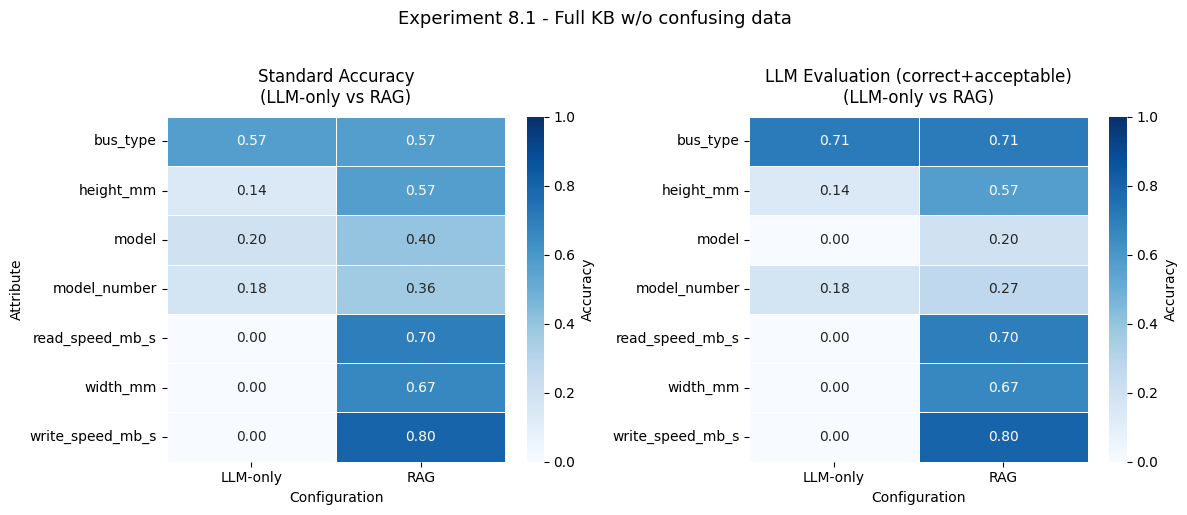

✓ Saved to fig_exp8_1_heatmap.png


: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load both files
results_llm = pd.read_csv("results_exp8_1_llm_only.csv")
results_rag = pd.read_csv("results_exp8_1_rag.csv")

# Make sure config labels are correct
results_llm["config"] = "LLM-only"
results_rag["config"] = "RAG"

all_results = pd.concat([results_llm, results_rag], ignore_index=True)

# Build heatmap data — standard accuracy
heatmap_data = (
    all_results.groupby(["attribute", "config"])["correct_standard"]
    .mean()
    .unstack("config")
    .reindex(columns=["LLM-only", "RAG"])
)

# Build heatmap data — LLM eval
heatmap_llm = (
    all_results.groupby(["attribute", "config"])
    .apply(lambda x: (x["llm_judgment"].isin(["correct", "acceptable"])).mean(),
           include_groups=False)
    .unstack("config")
    .reindex(columns=["LLM-only", "RAG"])
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    heatmap_data,
    annot=True, fmt=".2f",
    cmap="Blues", vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=axes[0], cbar_kws={"label": "Accuracy"}
)
axes[0].set_title("Standard Accuracy\n(LLM-only vs RAG)", fontsize=12, pad=10)
axes[0].set_xlabel("Configuration")
axes[0].set_ylabel("Attribute")
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(
    heatmap_llm,
    annot=True, fmt=".2f",
    cmap="Blues", vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=axes[1], cbar_kws={"label": "Accuracy"}
)
axes[1].set_title("LLM Evaluation (correct+acceptable)\n(LLM-only vs RAG)", fontsize=12, pad=10)
axes[1].set_xlabel("Configuration")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=0)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle("Experiment 8.1 - Full KB w/o confusing data", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig_exp8_1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved to fig_exp8_1_heatmap.png")